Fase 1 - Carga y preparación de datos

In [15]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
import spacy
DATA_PATH = "dataset_processed_full.csv"  # cambia si está en data/...
df = pd.read_csv(DATA_PATH)

df.shape, df.columns
df.head(3)

# Stopwords en español e inglés
STOP_ES = set(stopwords.words("spanish"))
STOP_EN = set(stopwords.words("english"))

#Lista manual de marcas que quieres eliminar de los tokens
BUSINESS_STOPWORDS = {
    "movistar", "orange", "vodafone", "yoigo", "o2", "jazztel",
    "telefonica", "telefónica", "lowi", "pepephone", "digi",
    "adamo", "masmovil", "másmovil", "simyo"
}

BUSINESS_STOPWORDS |= set(df["company"].dropna().astype(str).str.lower().unique())

nlp_es = spacy.load("es_core_news_sm", disable=["parser", "ner"])
nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])

#print("spaCy OK")

#detectar idioma 
def guess_language(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "es"
    #minúsculas y tokenización básica
    raw = text.lower()
    tokens = re.findall(r"\b\w+\b", raw)
    es_hits = sum(t in STOP_ES for t in tokens)
    en_hits = sum(t in STOP_EN for t in tokens)
    return "es" if es_hits >= en_hits else "en"

#Limpieza de tokens
def tokens_clean (text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    #minúsculas y eliminación de URLs y correos
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    #eliminación de puntuación y espacios extra
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    #Tokenización y lematización con spaCy
    nlp = nlp_es if guess_language(text) == "es" else nlp_en
    doc = nlp(text)

    cleaned = []
    for token in doc:
        if token.is_space:
            continue
        tok = token.lemma_.strip()
        if not tok or len(tok) < 2 or tok.isdigit():
            continue
        if tok in STOP_ES or tok in STOP_EN:
            continue
        if tok in BUSINESS_STOPWORDS:
            continue
        cleaned.append(tok)

    return " ".join(cleaned)

TEXT_COL = "review_text"

#crear nueva columna con tokens limpios
df["tokens_clean"] = df[TEXT_COL].apply(tokens_clean)

df[[TEXT_COL, "tokens_clean"]].head(10)
(df["tokens_clean"].str.strip() == "").mean()

df[["review_text", "tokens_clean"]].sample(15, random_state=42)

df.head(3)



,company,rating_web,review_text,processed_at,sentiment_label,sentiment_score,emotions,topics,pain_points,competitors,is_churn_risk,tokens_clean
0,Orange,1,Tras el fallecimiento del titular en el mes de...,2026-01-10T21:29:11.271199,Negativo,-0.8,"Frustración,Decepción","Servicio al cliente,Resolución de problemas","Respuesta insatisfactoria,Lack of empathy",NaN,True,tras fallecimiento titular mes noviembre haber...
1,Orange,1,Una decada con ellos y solo puedo decir que es...,2026-01-10T21:29:12.176956,Negativo,-0.9,"Frustración,Decepción","Servicio al cliente,Corte de tiempo","Costes excesivos,Malas condiciones de servicio",NaN,True,decado solo poder decir ser peor haber españa ...
2,Orange,1,Scam!They have taken away my mobile number tha...,2026-01-10T21:29:13.225578,Negativo,-1.0,"Frustración,Ira","Servicio al cliente,Deactivación de SIM,Credit...","Negativa del servicio al cliente,Desconocimien...",NaN,True,scamthey take away mobile number ’ve year deac...


Fase 4: Visualización

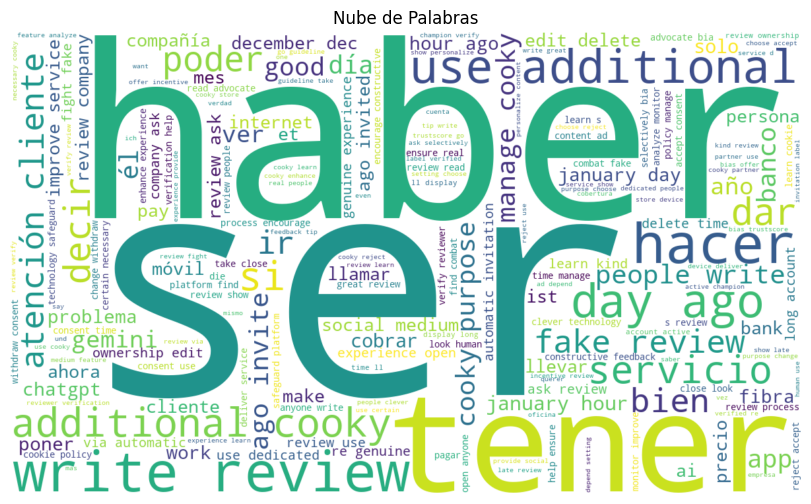

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

text_for_wc = " ".join(df["tokens_clean"].fillna("").astype(str).tolist()).strip()
wc = WordCloud(width=1200, height=700, background_color="white").generate(text_for_wc)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras")
plt.show()


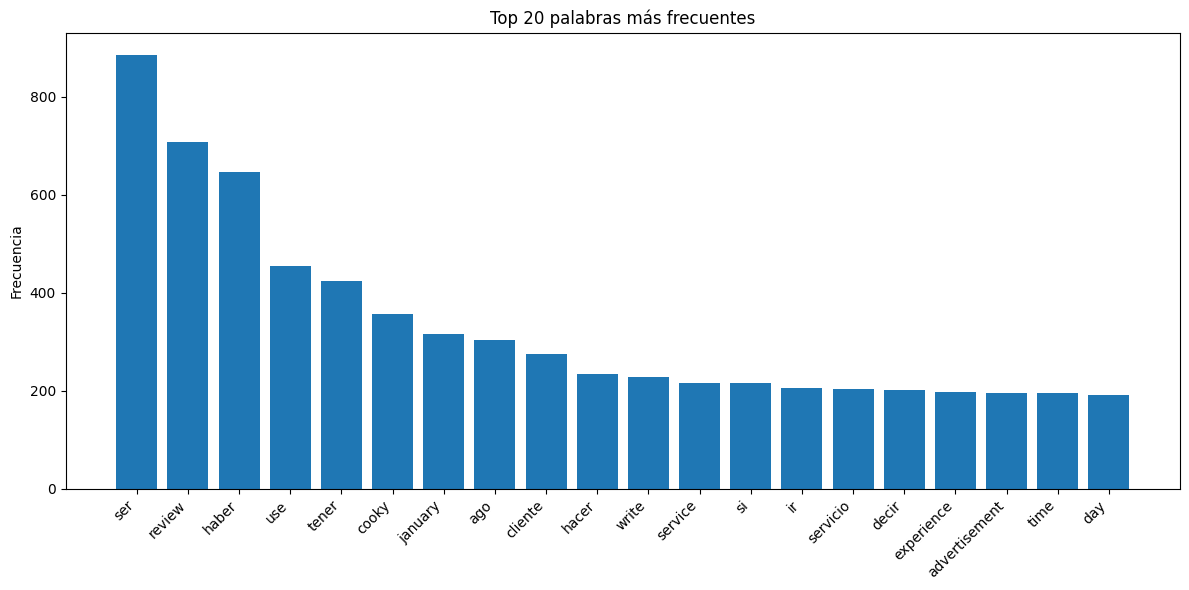

In [17]:
tokens = []
for row in df["tokens_clean"].fillna("").astype(str):
    tokens.extend(row.split())

top20 = Counter(tokens).most_common(20)
words, counts = zip(*top20) if top20 else ([], [])

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 palabras más frecuentes")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


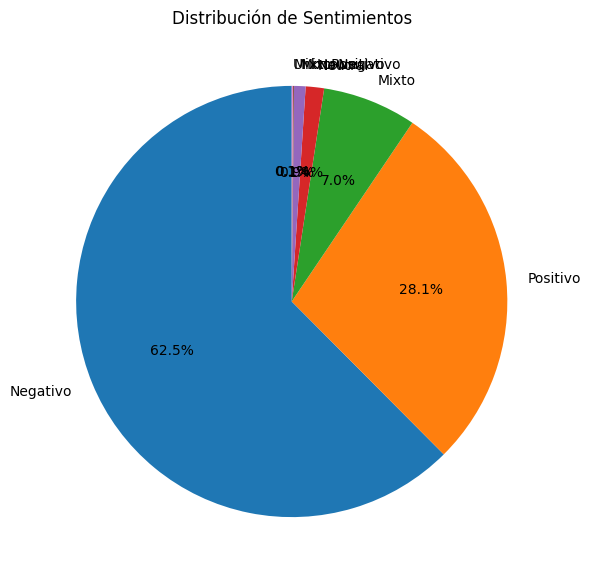

In [18]:
sent_counts = df["sentiment_label"].fillna("Unknown").value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    sent_counts.values,
    labels=sent_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de Sentimientos")
plt.show()
